In [21]:
# Environment Setup
from pathlib import Path
import sys
import matplotlib.pyplot as plt


def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_loading import load_csv_files, build_image_path
from src.preprocessing import (ImageClassificationDataset, get_train_transforms, get_eval_transforms, split_train_validation,)

# Loading the training set, then splitting it into train and validation subsets and checking that the class balance in both splits.
train_df, test_df = load_csv_files()
train_split_df, val_split_df = split_train_validation(train_df, val_size=0.2, seed=42)
print("Train split size:", len(train_split_df))
print("Validation split size:", len(val_split_df))
print("Train split class counts:\n", train_split_df["Category"].value_counts().sort_index())
print("Validation split class counts:\n", val_split_df["Category"].value_counts().sort_index())

Train split size: 13600
Validation split size: 3400
Train split class counts:
 Category
0    1360
1    1360
2    1360
3    1360
4    1360
5    1360
6    1360
7    1360
8    1360
9    1360
Name: count, dtype: int64
Validation split class counts:
 Category
0    340
1    340
2    340
3    340
4    340
5    340
6    340
7    340
8    340
9    340
Name: count, dtype: int64


Train dataset length: 13600
Validation dataset length: 3400
One transformed image tensor shape: torch.Size([1, 32, 32])
One transformed image tensor min/max: -1.0 1.0
One transformed label: 0


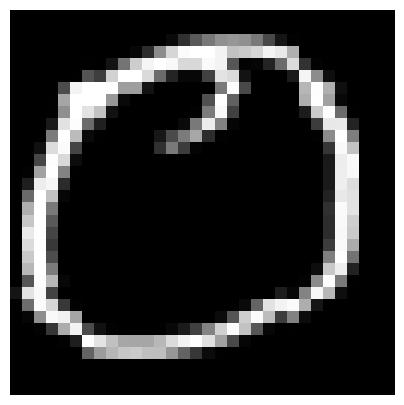

In [22]:
# Building the image transforms and datasets.
# train_transform is applying rotation, affine shifts, grayscale, resize, and normalization.
train_transform = get_train_transforms(image_size=32)
val_transform = get_eval_transforms(image_size=32)

# Building image paths from the split dataframes so each image stays matched to its label.
train_image_paths = [build_image_path(row.Id, split="train", label=row.Category) for row in train_split_df.itertuples(index=False)]
val_image_paths = [build_image_path(row.Id, split="train", label=row.Category) for row in val_split_df.itertuples(index=False)]

train_dataset = ImageClassificationDataset(
    image_paths=train_image_paths,
    labels=train_split_df["Category"].tolist(),
    transform=train_transform,
)
val_dataset = ImageClassificationDataset(
    image_paths=val_image_paths,
    labels=val_split_df["Category"].tolist(),
    transform=val_transform,
)

print("Train dataset length:", len(train_dataset))
print("Validation dataset length:", len(val_dataset))

# Inspecting one transformed sample to check that normalization scaled the values correctly to [-1, 1].
# Rotation and affine are random.
sample_x, sample_y = train_dataset[0]
print("One transformed image tensor shape:", sample_x.shape)
print("One transformed image tensor min/max:", float(sample_x.min()), float(sample_x.max()))
print("One transformed label:", sample_y)

plt.figure(figsize=(5, 5))
plt.imshow(sample_x.squeeze(0), cmap="gray")
plt.axis("off")
plt.show()